<a href="https://colab.research.google.com/github/PedroConst/EQE-358-Metodos-Numericos/blob/main/Lab/Lab_01_Solvente_Biodegrad%C3%A1vel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 01 – Ajuste de Capacidade Térmica**

## Objetivos
- Implementar regressão por mínimos quadrados
- Resolver um sistema linear em Python
- Avaliar a qualidade do ajuste com métricas estatísticas
- Visualizar dados experimentais

---

## Contexto

O calorímetro é um dispositivo termicamente isolado utilizado para medir trocas de calor entre corpos ou a energia liberada/absorvida em reações químicas e transformações físicas. Ele funciona como um sistema fechado que minimiza a troca de energia com o ambiente externo, permitindo analisar propriedades como o calor específico e a capacidade térmica.

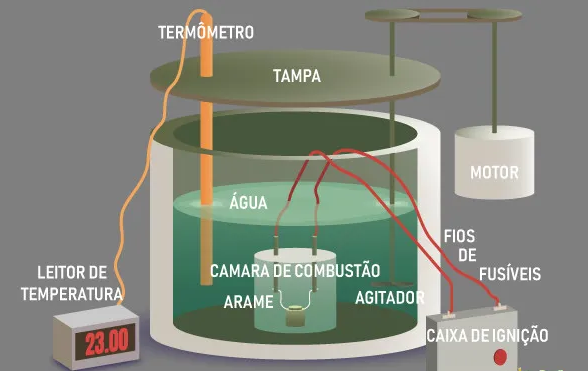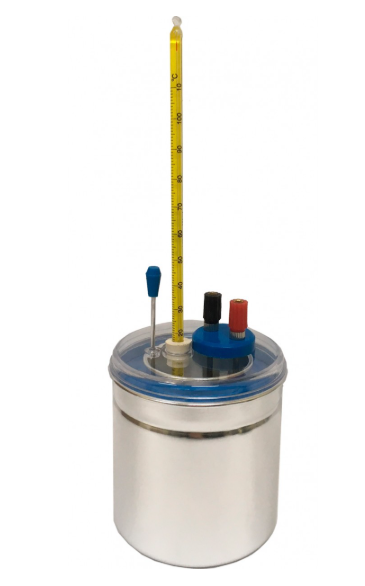

A Calorimetria de Varredura Diferencial (DSC) é uma técnica de análise térmica que mede a diferença de fluxo de calor entre uma amostra e uma referência em função da temperatura ou do tempo. É amplamente utilizada para caracterizar propriedades termofísicas de materiais.

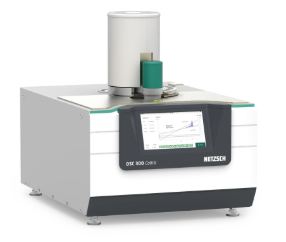


Foi medido experimentalmente o calor específico de um solvente bio-renovável
em função da temperatura.

Deseja-se ajustar o modelo:
$$
Cp(T) = a0 + a_1T + a_2T^2
\tag{1}
$$
utilizando mínimos quadrados.

##**🔹 Passo 1 – Importar bibliotecas**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 🔹 **Passo 2 – Inserir os dados experimentais**

Insira abaixo os vetores de temperatura (T) e capacidade térmica (Cp).

In [ ]:
# Responda aqui

T = np.array([...])
Cp = np.array([...])

##**🔹 Passo 3 – Construir a matriz do sistema**


Deseja-se ajustar o modelo:

$$
\hat{Cp}_i = a_0 + a_1 T_i + a_2 T_i^2
\tag{2}
$$

Definimos a função erro (soma dos quadrados):

$$
S(a_0,a_1,a_2) =
\sum_{i=1}^{n}
\left[
Cp_i - (a_0 + a_1 T_i + a_2 T_i^2)
\right]^2
\tag{3}
$$

O problema consiste em determinar $a_0, a_1, a_2$ que minimizam $S$.


Para minimizar $S$, impomos:

$$
\frac{\partial S}{\partial a_0} = 0,
\qquad
\frac{\partial S}{\partial a_1} = 0,
\qquad
\frac{\partial S}{\partial a_2} = 0
\tag{4}
$$

A derivação conduz ao seguinte sistema linear:

$$
\begin{cases}
n a_0 + a_1 \sum T_i + a_2 \sum T_i^2
=
\sum Cp_i
\\[6pt]
a_0 \sum T_i + a_1 \sum T_i^2 + a_2 \sum T_i^3
=
\sum T_i Cp_i
\\[6pt]
a_0 \sum T_i^2 + a_1 \sum T_i^3 + a_2 \sum T_i^4
=
\sum T_i^2 Cp_i
\end{cases}
\tag{5}
$$

### Forma Matricial

Este é um sistema linear 3×3 para os parâmetros $a_0, a_1, a_2$.
O sistema linear tem a forma:

$$
\mathbf{A}\mathbf{x} = \mathbf{b}
\tag{6}
$$

onde:

$$
\mathbf{x} =
\begin{bmatrix}
a_0 \\
a_1 \\
a_2
\end{bmatrix}
$$

$$
\mathbf{A} =
\begin{bmatrix}
n & \sum T_i & \sum T_i^2 \\
\sum T_i & \sum T_i^2 & \sum T_i^3 \\
\sum T_i^2 & \sum T_i^3 & \sum T_i^4
\end{bmatrix}
$$

$$
\mathbf{b} =
\begin{bmatrix}
\sum Cp_i \\
\sum T_i Cp_i \\
\sum T_i^2 Cp_i
\end{bmatrix}
$$

In [ ]:
# Número de pontos
n = len(T)

# Construa a matriz A
A = np.array([
    [..., ..., ...],
    [..., ..., ...],
    [..., ..., ...]
])

# Construa o vetor b
b = np.array([
    ...,
    ...,
    ...
])

## **🔹 Passo 4 – Resolver o sistema linear**

In [ ]:
coef = np.linalg.solve(A, b)

a0, a1, a2 = coef

print("Coeficientes ajustados:")
print("a0 =", a0)
print("a1 =", a1)
print("a2 =", a2)

## **🔹 Passo 5 – Construir a curva ajustada**

$$
\hat{Cp}_i = a_0 + a_1 T_i + a_2 T_i^2
$$

onde:

- $Cp_i$ = valor experimental  
- $\hat{Cp}_i$ = valor previsto pelo modelo  
- $n$ = número de observações

In [ ]:
T_model = np.linspace(min(T), max(T), 100)

Cp_model = ...

## **🔹 Passo 6 – Plotar resultados**

In [ ]:
plt.scatter(T, Cp, label="Dados experimentais")

plt.plot(T_model, Cp_model, label="Modelo ajustado")

plt.xlabel("Temperatura (K)")
plt.ylabel("Cp (kJ/kg.K)")
plt.legend()
plt.grid()
plt.show()

## **🔹 Passo 7 – Calcular resíduos**

$$
e_i = y_i - \hat{y}_i
\tag{7}
$$

Forma vetorial:

$$
\mathbf{e} = \mathbf{y} - \hat{\mathbf{y}}
\tag{8}
$$

In [ ]:
Cp_pred = ...

residuos = ...

## **🔹 Passo 8 – Calcular SSR e RMSE**

- Soma dos Quadrados dos Resíduos (SSR)

$$
SSR = \sum_{i=1}^{n} e_i^2
\tag{9}
$$

ou explicitamente:

$$
SSR = \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
\tag{10}
$$


In [ ]:
SSR = ...

print("SSR =", SSR)

- Erro Quadrático Médio (RMSE)

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} e_i^2}
\tag{11}
$$

ou

$$
RMSE = \sqrt{\frac{SSR}{n}}
\tag{12}
$$

In [ ]:
RMSE = ...

print("RMSE =", RMSE)

## **🔹 Passo 9 – Calcular R²**


- Média dos Valores Observados

$$
\bar{y} = \frac{1}{n} \sum_{i=1}^{n} y_i
\tag{13}
$$


In [ ]:
Cp_media = ...

print("Cp_medio =", Cp_media)

- Soma Total dos Quadrados (SST)

$$
SST = \sum_{i=1}^{n} \left( y_i - \bar{y} \right)^2
\tag{14}
$$


In [ ]:
SST = ...

print("SST =", SST)

- Coeficiente de Determinação (R²)

$$
R^2 = 1 - \frac{SSR}{SST}
\tag{15}
$$


In [ ]:
R2 = ...

print("R² =", R2)